## EE 460 Final Project

### Members:
Aaron Hui  
Osher Nodel  
Theodore Matsusaka  
Nathan Spare

##### Imports

In [197]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim

import optuna

# Suppress Optuna terminal spam (only show final study results)
optuna.logging.set_verbosity(optuna.logging.WARNING)

##### Dataset, Feature Extraction, and Feature Engineering

In [198]:
def process_temperature_folder(folder_path, bearing_col_idx=2, ambient_col_idx=3, separator=','):
    """
    Reads Kaggle run-to-failure CSV files and dynamically calculates Delta T 
    using the recorded atmospheric temperature.
    """
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv') or f.endswith('.txt')])
    data_list = []
    
    print(f"Extracting temperature from {len(files)} files...")
    
    for i, filename in enumerate(files):
        try:
            file_path = os.path.join(folder_path, filename)
            
            # Read the file (Kaggle datasets are typically comma-separated)
            raw_data = pd.read_csv(file_path, sep=separator, header=None)
            
            # Extract mean bearing temp (Index 2) and mean atmospheric temp (Index 3)
            mean_bearing_temp = raw_data[bearing_col_idx].mean()
            mean_ambient_temp = raw_data[ambient_col_idx].mean()
            
            # Calculate the true thermodynamic differential
            delta_t = mean_bearing_temp - mean_ambient_temp
            
            data_list.append({'Window_ID': i, 'Delta_T': delta_t})
            print(f"Processed {filename}: Delta_T = {delta_t:.2f}°C")
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            
    return pd.DataFrame(data_list)

In [199]:
def engineer_temperature_features(df, temp_col='Delta_T', window=15):
    """
    Expands 1D temperature into a rich kinematic and statistical feature space.
    """
    df_feat = df.copy()
    
    # 1. Rolling Statistics (Contextual Memory)
    df_feat['Temp_Rolling_Mean'] = df_feat[temp_col].rolling(window=window).mean()
    df_feat['Temp_Rolling_Std']  = df_feat[temp_col].rolling(window=window).std()
    
    # 2. Kinematics (Derivatives)
    df_feat['Temp_Velocity']     = df_feat[temp_col].diff()
    df_feat['Temp_Acceleration'] = df_feat['Temp_Velocity'].diff()
    
    # 3. Cumulative Metrics (Total Stress) - ONLY for Supervised Models!
    df_feat['Temp_Cumulative_Heat'] = df_feat[temp_col].cumsum()
    
    # Drop NaNs caused by rolling calculations to ensure clean arrays
    df_feat = df_feat.dropna().reset_index(drop=True)
    return df_feat

In [200]:
def generate_multitier_labels(df, feature_col='Delta_T', window_size=25):
    """
    Creates labels based on the actual thermodynamic journey of the dataset,
    scaling dynamically to the maximum recorded degradation.
    """
    df_labeled = df.copy()
    total_length = len(df_labeled)
    
    # 1. Establish stable baseline
    start_idx = int(total_length * 0.1)
    end_idx = int(total_length * 0.3)
    baseline_data = df_labeled[feature_col].iloc[start_idx:end_idx]
    
    baseline_median = baseline_data.median()
    baseline_std = baseline_data.std()
    
    # Find the maximum temperature reached before failure
    max_temp = df_labeled[feature_col].max()
    total_degradation = max_temp - baseline_median
    
    # 2. THE FIX: Percentage-Based Degradation Triggers
    # Warning: Triggers when the bearing completes 15% of its journey to failure, OR 3-sigma (whichever is larger)
    warning_shift = max(total_degradation * 0.15, 3 * baseline_std)
    
    # Critical: Triggers when the bearing reaches 70% of its journey to failure
    critical_shift = max(total_degradation * 0.70, 6 * baseline_std)
    
    warning_trigger = baseline_median + warning_shift
    critical_trigger = baseline_median + critical_shift
    
    # 3. Debounce using a rolling mean
    rolling_mean = df_labeled[feature_col].rolling(window=window_size).mean()
    valid_windows = df_labeled.index > start_idx
    
    warning_breaches = np.where((rolling_mean > warning_trigger) & valid_windows)[0]
    critical_breaches = np.where((rolling_mean > critical_trigger) & valid_windows)[0]
    
    # 4. Set indices
    onset_warning = warning_breaches[0] if len(warning_breaches) > 0 else int(total_length * 0.60)
    onset_critical = critical_breaches[0] if len(critical_breaches) > 0 else int(total_length * 0.85)
    
    # 5. Apply labels
    df_labeled['label_warning'] = 0
    df_labeled.loc[onset_warning:, 'label_warning'] = 1
    
    df_labeled['label_critical'] = 0
    df_labeled.loc[onset_critical:, 'label_critical'] = 1
    
    return df_labeled, onset_warning, warning_trigger, onset_critical, critical_trigger

In [201]:
def plot_multitier_verification(df, feature_col, onset_warn, trig_warn, onset_crit, trig_crit):
    plt.figure(figsize=(12, 5))
    
    plt.plot(df.index, df[feature_col], color='gray', alpha=0.4, label=f'Raw {feature_col}')
    rolling_mean = df[feature_col].rolling(window=25).mean()
    plt.plot(df.index, rolling_mean, color='blue', alpha=0.8, linewidth=1.5, label='Rolling Mean (Debounce)')
    
    # Warning Logic (Yellow)
    plt.axhline(y=trig_warn, color='#ff7f0e', linestyle='--', label='Warning Trigger (3-Std)')
    plt.axvline(x=onset_warn, color='#ff7f0e', linewidth=2, label=f'Warning Onset ({onset_warn})')
    
    # Critical Logic (Red)
    plt.axhline(y=trig_crit, color='#d62728', linestyle='--', label='Critical Trigger (6-Std)')
    plt.axvline(x=onset_crit, color='#d62728', linewidth=2, label=f'Critical Onset ({onset_crit})')
    
    # Highlight zones
    plt.axvspan(onset_warn, onset_crit, color='yellow', alpha=0.2, label='Degradation Zone')
    plt.axvspan(onset_crit, len(df), color='red', alpha=0.2, label='Failure Zone')
    plt.axvspan(0, int(len(df)*0.1), color='black', alpha=0.1, label='Ignored Startup (10%)')
    
    plt.title(f"Multi-Tier Detection Logic Check: {feature_col}", fontsize=14)
    plt.xlabel("Timeline (Sequential Windows)")
    plt.ylabel("Temperature Differential")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

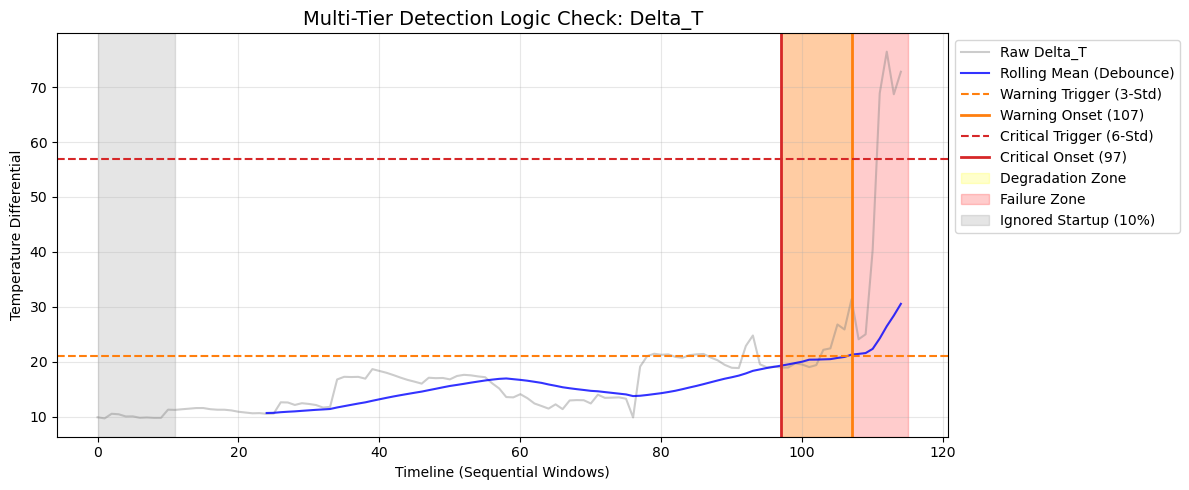

In [202]:
# raw_temp_df = process_temperature_folder('kaggle_raw_data')
# raw_temp_df.to_csv('kaggle_cleaned_features.csv', index=False)
raw_temp_df = pd.read_csv('kaggle_cleaned_features.csv')

# 1. Engineer Features
engineered_df = engineer_temperature_features(raw_temp_df)

# 2. Apply Multi-Tier Labels
final_df, o_warn, t_warn, o_crit, t_crit = generate_multitier_labels(engineered_df, 'Delta_T')
plot_multitier_verification(final_df, 'Delta_T', o_warn, t_warn, o_crit, t_crit)

# 3. Define Feature Pools
all_features = ['Delta_T', 'Temp_Rolling_Mean', 'Temp_Rolling_Std', 
                'Temp_Velocity', 'Temp_Acceleration', 'Temp_Cumulative_Heat']

ae_safe_features = [f for f in all_features if f not in ['Temp_Cumulative_Heat', 'Window_ID']]

# 4. Supervised Split (Random Stratified on Critical Failure)
X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(
    final_df[all_features], final_df['label_critical'], 
    test_size=0.3, random_state=42, stratify=final_df['label_critical']
)

# 5. Unsupervised Split (Chronological for Autoencoder)
split_idx = int(len(final_df) * 0.4) # Train strictly on first 40% (Healthy)
healthy_chronological = final_df.iloc[:split_idx]
test_chronological = final_df.iloc[split_idx:]

##### Logistic Regression + MLP (Supervised Models)

In [203]:
print("\n--- Optimizing Supervised Models (Target: Critical Failure) ---")

def objective_lr(trial):
    selected = [col for col in all_features if trial.suggest_categorical(f"use_{col}", [True, False])]
    if len(selected) == 0: return 0.0

    X_tr_sub, X_te_sub = X_train_sup[selected], X_test_sup[selected]
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_sub)
    X_te_scaled = scaler.transform(X_te_sub)
    
    c_val = trial.suggest_float("C", 1e-4, 1e2, log=True)
    model = LogisticRegression(C=c_val, max_iter=1000, class_weight='balanced', solver='liblinear')
    model.fit(X_tr_scaled, y_train_sup)
    
    preds = model.predict(X_te_scaled)
    # Penalize feature bloat
    return f1_score(y_test_sup, model.predict(X_te_scaled)) - (0.005 * len(selected))


--- Optimizing Supervised Models (Target: Critical Failure) ---


In [204]:
def objective_mlp(trial):
    selected = ['Temp_Cumulative_Heat'] 
    for col in all_features:
        if col != 'Temp_Cumulative_Heat' and trial.suggest_categorical(f"use_{col}", [True, False]):
            selected.append(col)

    X_tr_sub, X_te_sub = X_train_sup[selected], X_test_sup[selected]
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_sub)
    X_te_scaled = scaler.transform(X_te_sub)
    
    n_neurons = trial.suggest_int('n_neurons', 2, 12)
    solver_choice = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    
    # THE NEW FIXES: Let Optuna leash the model and test a smoother activation
    alpha_val = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    activation_choice = trial.suggest_categorical('activation', ['relu', 'tanh'])
    
    model = MLPClassifier(
        hidden_layer_sizes=(n_neurons,), 
        solver=solver_choice, 
        activation=activation_choice,
        alpha=alpha_val,
        max_iter=2000, 
        random_state=42
    )
    model.fit(X_tr_scaled, y_train_sup)
    
    return f1_score(y_test_sup, model.predict(X_te_scaled)) - (0.005 * len(selected))

In [205]:
study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=30)
best_lr_feats = [col for col in all_features if study_lr.best_params.get(f"use_{col}", False)]

study_mlp = optuna.create_study(direction="maximize")
study_mlp.optimize(objective_mlp, n_trials=30)
best_mlp_feats = ['Temp_Cumulative_Heat'] + [col for col in all_features if col != 'Temp_Cumulative_Heat' and study_mlp.best_params.get(f"use_{col}", False)]

##### Autoencoder (Unsupervised Model)

In [206]:
print("--- Optimizing Dense Autoencoder (Target: Early Warning) ---")

ae_scaler = StandardScaler()
X_healthy_scaled = ae_scaler.fit_transform(healthy_chronological[ae_safe_features])
X_test_chron_scaled = ae_scaler.transform(test_chronological[ae_safe_features])

# Convert directly to 2D Tensors (No sequences needed!)
X_train_ae = torch.tensor(X_healthy_scaled, dtype=torch.float32)
X_test_ae = torch.tensor(X_test_chron_scaled, dtype=torch.float32)
y_test_ae_warn = test_chronological['label_warning'].values

def objective_ae(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 2, 4)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    class DenseAutoencoder(nn.Module):
        def __init__(self, hidden_size):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(len(ae_safe_features), hidden_size),
                nn.ReLU()
            )
            self.decoder = nn.Sequential(
                nn.Linear(hidden_size, len(ae_safe_features))
            )

        def forward(self, x):
            return self.decoder(self.encoder(x))

    model_ae = DenseAutoencoder(hidden_size=hidden_dim)
    optimizer = optim.Adam(model_ae.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Train for validation split
    val_split = int(len(X_train_ae) * 0.8)
    tr_data, val_data = X_train_ae[:val_split], X_train_ae[val_split:]
    
    for epoch in range(15):
        model_ae.train()
        optimizer.zero_grad()
        loss = criterion(model_ae(tr_data), tr_data)
        loss.backward()
        optimizer.step()
        
    model_ae.eval()
    with torch.no_grad():
        val_loss = criterion(model_ae(val_data), val_data).item()
    return val_loss

study_ae = optuna.create_study(direction="minimize")
study_ae.optimize(objective_ae, n_trials=15)

--- Optimizing Dense Autoencoder (Target: Early Warning) ---


##### Evaluation

In [207]:
# 1. Final LR with Probability Thresholding
scaler_lr = StandardScaler()
X_tr_lr = scaler_lr.fit_transform(X_train_sup[best_lr_feats])
X_te_lr = scaler_lr.transform(X_test_sup[best_lr_feats])

final_lr = LogisticRegression(C=study_lr.best_params['C'], max_iter=1000, class_weight='balanced', solver='liblinear')
final_lr.fit(X_tr_lr, y_train_sup)

# THE FIX: Get the raw probabilities instead of the default 0/1 predictions
lr_probs = final_lr.predict_proba(X_te_lr)[:, 1]

# Sweep to find the exact probability threshold that maximizes the F1 score
best_f1_lr, best_lr_thresh = 0, 0.5
for thresh in np.linspace(0.1, 0.9, 80):
    score = f1_score(y_test_sup, (lr_probs >= thresh).astype(int))
    if score > best_f1_lr:
        best_f1_lr = score
        best_lr_thresh = thresh

# Re-assign f1_lr so the leaderboard prints the improved score
f1_lr = best_f1_lr
lr_test_preds = (lr_probs >= best_lr_thresh).astype(int)

# 2. Final MLP with Probability Thresholding
scaler_mlp = StandardScaler()
X_tr_mlp = scaler_mlp.fit_transform(X_train_sup[best_mlp_feats])
X_te_mlp = scaler_mlp.transform(X_test_sup[best_mlp_feats])

final_mlp = MLPClassifier(
    hidden_layer_sizes=(study_mlp.best_params['n_neurons'],), 
    solver=study_mlp.best_params['solver'],
    activation=study_mlp.best_params['activation'], # Pass winning activation
    alpha=study_mlp.best_params['alpha'],           # Pass winning alpha
    max_iter=2000, 
    random_state=42
)
final_mlp.fit(X_tr_mlp, y_train_sup)

mlp_probs = final_mlp.predict_proba(X_te_mlp)[:, 1]

best_f1_mlp, best_mlp_thresh = 0, 0.5
for thresh in np.linspace(0.1, 0.9, 80):
    score = f1_score(y_test_sup, (mlp_probs >= thresh).astype(int))
    if score > best_f1_mlp:
        best_f1_mlp = score
        best_mlp_thresh = thresh

f1_mlp = best_f1_mlp
mlp_test_preds = (mlp_probs >= best_mlp_thresh).astype(int)

# 3. Final Dense Autoencoder & Dynamic Thresholding
class FinalDenseAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(len(ae_safe_features), study_ae.best_params['hidden_dim']),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(study_ae.best_params['hidden_dim'], len(ae_safe_features))
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

final_ae = FinalDenseAE()
optimizer = optim.Adam(final_ae.parameters(), lr=study_ae.best_params['lr'])
criterion = nn.MSELoss()

for epoch in range(25): 
    final_ae.train()
    optimizer.zero_grad()
    loss = criterion(final_ae(X_train_ae), X_train_ae)
    loss.backward()
    optimizer.step()

final_ae.eval()
with torch.no_grad():
    raw_test_mse = torch.mean((final_ae(X_test_ae) - X_test_ae)**2, dim=1).numpy()
    raw_healthy_mse = torch.mean((final_ae(X_train_ae) - X_train_ae)**2, dim=1).numpy()

# THE FIX: Apply a 5-window rolling average to smooth out the noise
test_mse = pd.Series(raw_test_mse).rolling(window=5, min_periods=1).mean().values
healthy_mse = pd.Series(raw_healthy_mse).rolling(window=5, min_periods=1).mean().values

# Calibrate against Warning Labels using the smoothed MSE
candidates = np.linspace(np.max(healthy_mse), np.max(test_mse), num=100)
best_f1_ae, best_thresh = 0, 0
for thresh in candidates:
    score = f1_score(y_test_ae_warn, (test_mse > thresh).astype(int))
    if score > best_f1_ae:
        best_f1_ae, best_thresh = score, thresh

In [208]:
# Parameter Calculations
lr_params = final_lr.coef_.size + final_lr.intercept_.size
mlp_params = sum(matrix.size for matrix in final_mlp.coefs_) + sum(vector.size for vector in final_mlp.intercepts_)
ae_params = sum(p.numel() for p in final_ae.parameters() if p.requires_grad)

print("\n" + "="*65)
print(" FINAL THERMODYNAMICS MODEL LEADERBOARD (DENSE ARCHITECTURE)")
print("="*65)
print(f"[CRITICAL ALERT] Logistic Regression F1 : {f1_lr:.4f}")
print(f"                 Total Parameters       : {lr_params} (Ultra-Lightweight)")
print(f"                 Selected Features      : {best_lr_feats}")
print("-" * 65)
print(f"[CRITICAL ALERT] MLP Classifier F1      : {f1_mlp:.4f}")
print(f"                 Total Parameters       : {mlp_params}")
print(f"                 Selected Features      : {best_mlp_feats}")
print("-" * 65)
print(f"[EARLY WARNING]  Dense Autoencoder F1   : {best_f1_ae:.4f}")
print(f"                 Total Parameters       : {ae_params}")
print(f"                 MSE Threshold          : {best_thresh:.4f}")
print(f"                 Safe Features Used     : {ae_safe_features}")
print("="*65)


 FINAL THERMODYNAMICS MODEL LEADERBOARD (DENSE ARCHITECTURE)
[CRITICAL ALERT] Logistic Regression F1 : 1.0000
                 Total Parameters       : 6 (Ultra-Lightweight)
                 Selected Features      : ['Delta_T', 'Temp_Rolling_Mean', 'Temp_Velocity', 'Temp_Acceleration', 'Temp_Cumulative_Heat']
-----------------------------------------------------------------
[CRITICAL ALERT] MLP Classifier F1      : 1.0000
                 Total Parameters       : 37
                 Selected Features      : ['Temp_Cumulative_Heat', 'Temp_Rolling_Std']
-----------------------------------------------------------------
[EARLY WARNING]  Dense Autoencoder F1   : 0.9412
                 Total Parameters       : 27
                 MSE Threshold          : 15.0541
                 Safe Features Used     : ['Delta_T', 'Temp_Rolling_Mean', 'Temp_Rolling_Std', 'Temp_Velocity', 'Temp_Acceleration']


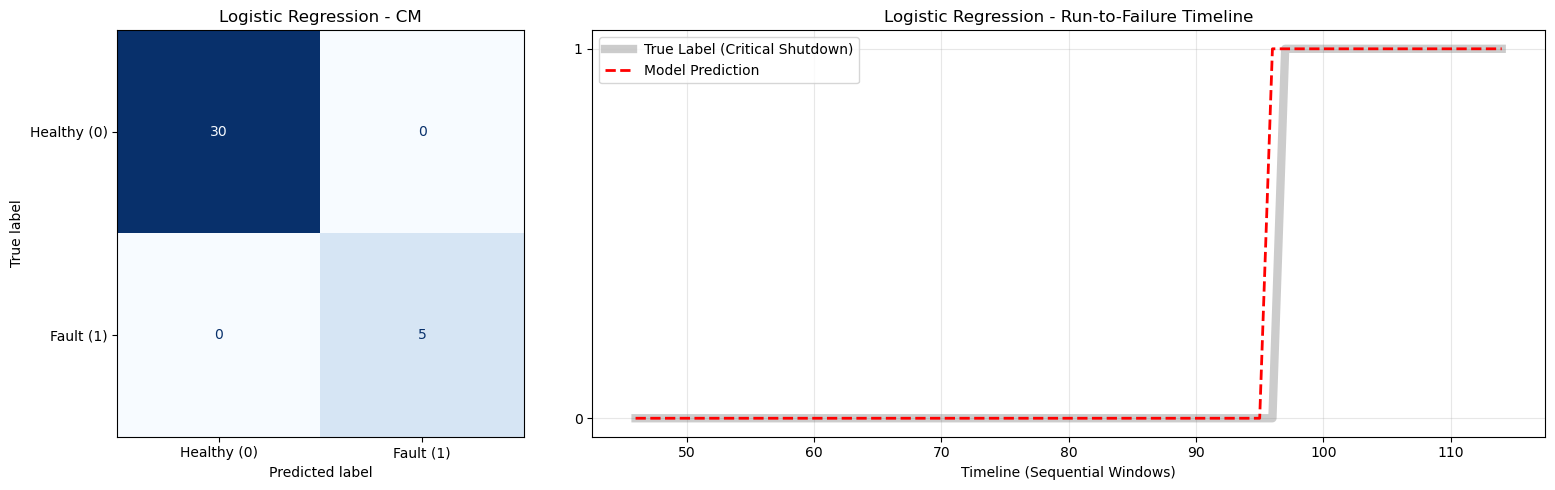

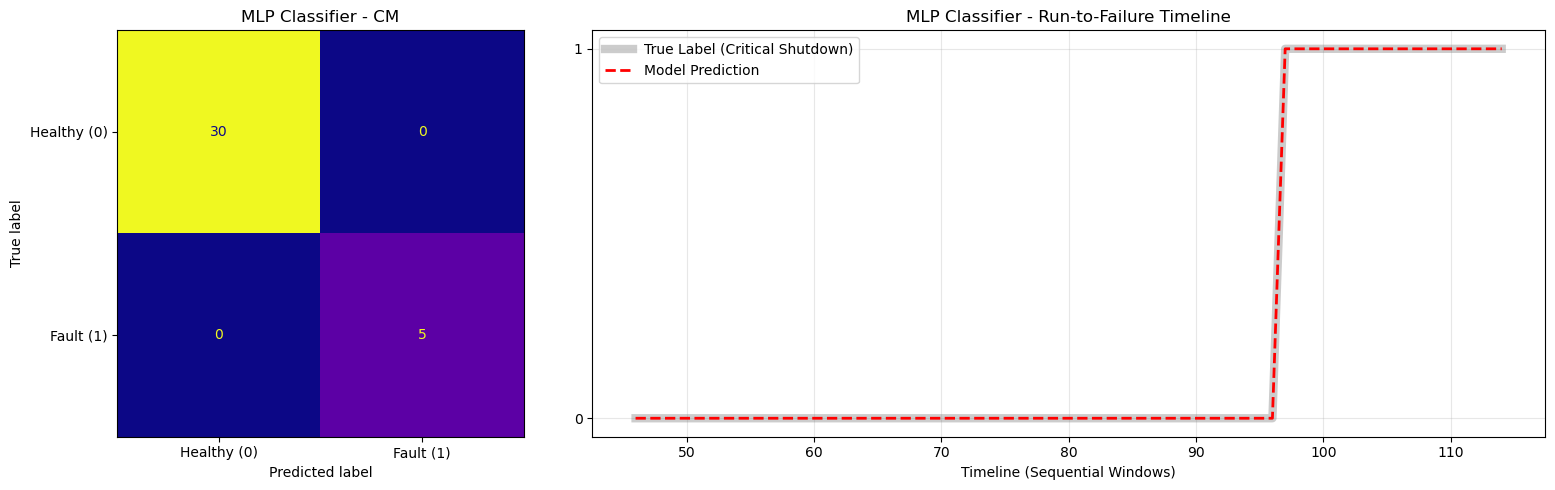

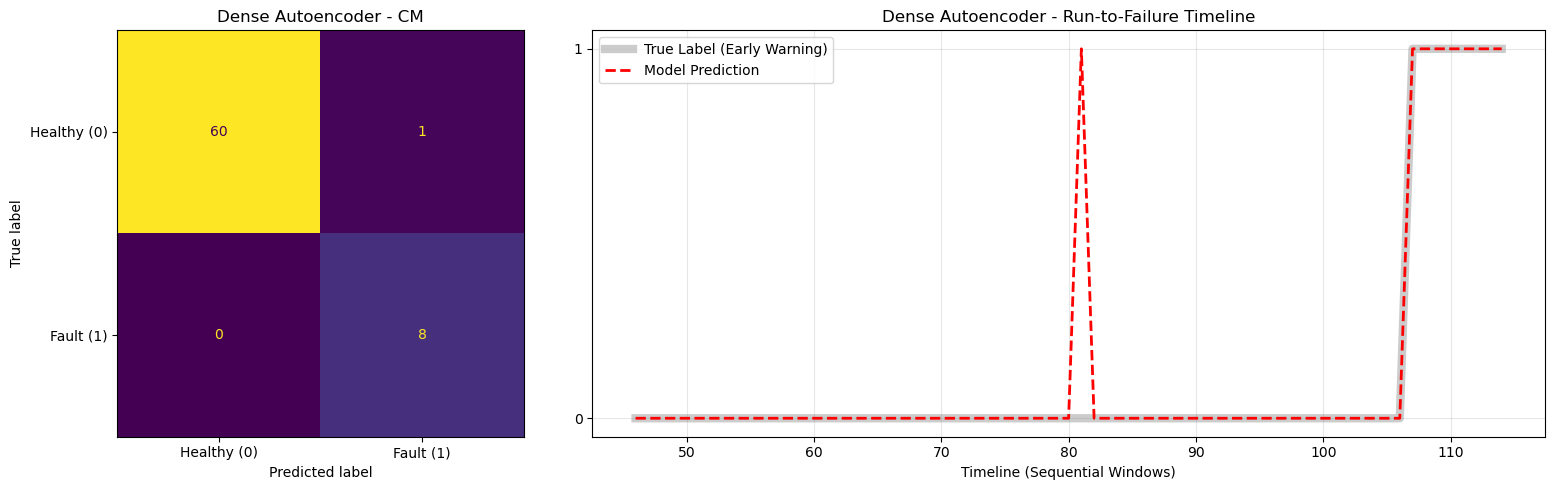

In [210]:
def plot_model_dashboard(model_name, cm_true, cm_preds, chron_true, chron_preds, timeline_idx, target_name, cmap='Blues'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 2]})
    
    # Left: Confusion Matrix
    cm = confusion_matrix(cm_true, cm_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Fault (1)'])
    disp.plot(ax=ax1, cmap=cmap, colorbar=False)
    ax1.set_title(f"{model_name} - CM", fontsize=12)
    
    # Right: Timeline Graph
    ax2.plot(timeline_idx, chron_true, label=f"True Label ({target_name})", color='gray', alpha=0.4, linewidth=6)
    ax2.plot(timeline_idx, chron_preds, label="Model Prediction", color='red', linestyle='--', linewidth=2)
    
    ax2.set_title(f"{model_name} - Run-to-Failure Timeline", fontsize=12)
    ax2.set_xlabel("Timeline (Sequential Windows)")
    ax2.set_yticks([0, 1])
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Extract chronological predictions for Supervised Models
X_chron_lr = scaler_lr.transform(test_chronological[best_lr_feats])
lr_chron_preds = final_lr.predict(X_chron_lr)

X_chron_mlp = scaler_mlp.transform(test_chronological[best_mlp_feats])
mlp_chron_preds = final_mlp.predict(X_chron_mlp)

# Plot Dashboards
plot_model_dashboard("Logistic Regression", y_test_sup, lr_test_preds, 
                     test_chronological['label_critical'], lr_chron_preds, 
                     test_chronological.index, "Critical Shutdown", cmap='Blues')

plot_model_dashboard("MLP Classifier", y_test_sup, mlp_test_preds, 
                     test_chronological['label_critical'], mlp_chron_preds, 
                     test_chronological.index, "Critical Shutdown", cmap='plasma')

plot_model_dashboard("Dense Autoencoder", y_test_ae_warn, (test_mse > best_thresh).astype(int), 
                     y_test_ae_warn, (test_mse > best_thresh).astype(int), 
                     test_chronological.index, "Early Warning", cmap='viridis')